# Candidate Selection (from parity/postprocessing)

Use this section first if you want to select potentially informative structures from `train_pred.pckl.gzip` / `test_pred.pckl.gzip` and export them for the active-learning MD protocol.

The ranking is *not* based on force RMS alone. It combines available signals such as:
- force RMS (global force error)
- max force error (localized bad atoms)
- energy error per atom (if energies exist)
- force-weighted emphasis on low-force structures (optional)

Then it exports selected structures (if an ASE-atoms column is present) into a folder that can be used as input for the AL run generator below.


In [1]:
import gzip
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

from ase import Atoms
from ase.io import read, write
from ase.visualize import view
from ase.formula import Formula

pd.set_option('display.max_colwidth', None)

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots

In [2]:
SEL = {
    # prediction files
    'pred_files': ['train_pred.pckl.gzip', 'test_pred.pckl.gzip'],

    # optional master dataset (full dated pickle) to recover atoms objects by name
    'master_glob': '20*.pkl.gzip',    # e.g. 20260219.pkl.gzip; latest match is used
    'use_master_atoms': True,

    # where to save exported structures for AL generation
    'export_dir': Path('selected_structures'),
    'name_trim_prefixes': ['/nfshome/sicolo/work/MLIP/dft_db/'],

    # selection strategy
    'source_priority': 'all',   # 'test_first', 'all', 'train_only', 'test_only'
    'top_k_total': None,              # choose after inspecting al_score distribution
    'top_k_per_split': None,          # e.g. 20 to cap train/test separately
    'min_al_score': None,            # optional score threshold (applied after ranking)
    'max_per_formula': None,            # None to disable; reduces duplicates by composition

    # metric weights (used if metric is available)
    'w_force_rms': 1.0,
    'w_force_max': 0.6,
    'w_energy_pa': 0.8,

    # optional emphasis on low-force regimes (scientifically useful if you care about phonons/relaxations)
    'use_relative_force_error': True,
    'relative_force_floor': 0.05,     # eV/A floor to avoid blow-up near zero forces
    'w_force_rel': 0.5,

    # export format
    'export_fmt': 'vasp',             # 'vasp' -> POSCAR_*.vasp
    'export_prefix': 'POSCAR_sel_',
}

SEL


{'pred_files': ['train_pred.pckl.gzip', 'test_pred.pckl.gzip'],
 'master_glob': '20*.pkl.gzip',
 'use_master_atoms': True,
 'export_dir': PosixPath('selected_structures'),
 'name_trim_prefixes': ['/nfshome/sicolo/work/MLIP/dft_db/'],
 'source_priority': 'all',
 'top_k_total': None,
 'top_k_per_split': None,
 'min_al_score': None,
 'max_per_formula': None,
 'w_force_rms': 1.0,
 'w_force_max': 0.6,
 'w_energy_pa': 0.8,
 'use_relative_force_error': True,
 'relative_force_floor': 0.05,
 'w_force_rel': 0.5,
 'export_fmt': 'vasp',
 'export_prefix': 'POSCAR_sel_'}

In [3]:
def _load_pred_df(path):
    with gzip.open(path, 'rb') as f:
        obj = pickle.load(f)
    if not isinstance(obj, pd.DataFrame):
        raise TypeError(f'{path} does not contain a pandas DataFrame (got {type(obj)})')
    return obj.copy()


def _trim_name_series(s, prefixes):
    s = s.astype(str)
    if prefixes:
        for pref in prefixes:
            s = s.str.removeprefix(pref)
    return s


def _resolve_master_file(sel):
    if not sel.get('use_master_atoms', False):
        return None
    pattern = sel.get('master_glob')
    if not pattern:
        return None
    matches = [p for p in Path('.').glob(pattern) if p.is_file()]
    if not matches:
        print(f'No master dataset matches found for pattern: {pattern}')
        return None
    latest = max(matches, key=lambda p: p.stat().st_mtime)
    print(f'Using master dataset for atoms merge: {latest}')
    return latest


def _merge_master_atoms(pred_df, sel):
    master_path = _resolve_master_file(sel)
    if master_path is None:
        return pred_df

    master = _load_pred_df(master_path)
    if 'name' not in pred_df.columns or 'name' not in master.columns:
        print('Skipping master merge: missing name column in pred or master dataframe')
        return pred_df

    atoms_col = next((c for c in ['ase_atoms', 'atoms', 'structure'] if c in master.columns), None)
    if atoms_col is None:
        print('Skipping master merge: no atoms column found in master dataframe')
        return pred_df

    prefixes = sel.get('name_trim_prefixes')
    out = pred_df.copy()
    out['_name_key'] = _trim_name_series(out['name'], prefixes)

    m = master[['name', atoms_col]].copy()
    m['_name_key'] = _trim_name_series(m['name'], prefixes)
    m = m.dropna(subset=['_name_key']).drop_duplicates(subset=['_name_key'], keep='first')
    m = m.rename(columns={atoms_col: 'ase_atoms'})[['_name_key', 'ase_atoms']]

    already_has_atoms = any(c in out.columns for c in ['ase_atoms', 'atoms', 'structure'])
    if already_has_atoms:
        print('Prediction dataframe already has atoms objects; skipping master atoms merge')
        return out.drop(columns=['_name_key'])

    before = len(out)
    out = out.merge(m, on='_name_key', how='left')
    matched = out['ase_atoms'].notna().sum() if 'ase_atoms' in out.columns else 0
    print(f'Master atoms merge matched {matched}/{before} rows by name')
    return out.drop(columns=['_name_key'])


def _as_np(x):
    return np.asarray(x, dtype=float)


def _force_metrics(row, rel_floor=0.05):
    out = {}
    if 'forces' not in row or 'forces_pred' not in row:
        return out
    try:
        f_true = _as_np(row['forces'])
        f_pred = _as_np(row['forces_pred'])
        out['force_shape_ok'] = bool(f_true.shape == f_pred.shape)
        if f_true.shape != f_pred.shape:
            return out
        diff = f_pred - f_true
        out['force_rmse'] = float(np.sqrt(np.mean(diff**2)))
        out['force_rms'] = out['force_rmse']  # backward-compatible alias
        out['force_mae'] = float(np.mean(np.abs(diff)))
        out['force_rmse_ge_mae'] = bool(out['force_rmse'] >= out['force_mae'])
        atom_err = np.sqrt(np.mean(diff**2, axis=1)) if diff.ndim == 2 else np.abs(diff)
        out['force_max_atom'] = float(np.max(atom_err))

        if f_true.ndim == 2:
            f_true_mag = np.linalg.norm(f_true, axis=1)
            f_err_mag = np.linalg.norm(diff, axis=1)
            rel = f_err_mag / np.maximum(f_true_mag, rel_floor)
            out['force_rel_mean'] = float(np.mean(rel))
            out['force_rel_p90'] = float(np.percentile(rel, 90))
            out['force_true_mag_mean'] = float(np.mean(f_true_mag))
    except Exception:
        pass
    return out


def _energy_metrics(row):
    out = {}

    # Prefer corrected reference energy when available; energy_err_pa is based on corrected total energy.
    e_true_total = None
    for k in ['energy_corrected', 'energy', 'energy_true', 'energies', 'E']:
        if k in row and pd.notna(row[k]):
            e_true_total = float(row[k])
            out['energy_target_key'] = k
            break

    e_pred_total = None
    for k in ['energy_pred', 'energies_pred', 'E_pred']:
        if k in row and pd.notna(row[k]):
            e_pred_total = float(row[k])
            out['energy_pred_key'] = k
            break

    if e_true_total is None or e_pred_total is None:
        return out

    de_total = e_pred_total - e_true_total
    out['energy_residual'] = de_total
    out['energy_err_abs'] = abs(de_total)

    n_atoms = None
    if 'natoms' in row and pd.notna(row['natoms']):
        n_atoms = int(row['natoms'])
    elif 'NUMBER_OF_ATOMS' in row and pd.notna(row['NUMBER_OF_ATOMS']):
        n_atoms = int(row['NUMBER_OF_ATOMS'])
    elif 'forces' in row:
        n_atoms = len(row['forces'])
    elif 'ase_atoms' in row:
        n_atoms = len(row['ase_atoms'])
    elif 'atoms' in row:
        n_atoms = len(row['atoms'])

    if n_atoms and n_atoms > 0:
        out['energy_err_pa'] = abs(de_total) / n_atoms
        out['energy_residual_pa'] = de_total / n_atoms
        out['natoms'] = n_atoms

    # Diagnostics: compare to corrected per-atom target if present
    if 'energy_corrected_per_atom' in row and pd.notna(row['energy_corrected_per_atom']) and n_atoms and n_atoms > 0:
        e_corr_pa = float(row['energy_corrected_per_atom'])
        out['energy_corrected_per_atom'] = e_corr_pa
        out['energy_pred_per_atom'] = e_pred_total / n_atoms
        out['energy_err_pa_direct_check'] = abs((e_pred_total / n_atoms) - e_corr_pa)

    return out


def _get_formula(row):
    for key in ['formula', 'chemical_formula', 'formula_pretty']:
        if key in row and pd.notna(row[key]):
            return str(row[key])

    if isinstance(row, dict):
        for key in ['ase_atoms', 'atoms', 'structure']:
            atoms_obj = row.get(key, None)
            try:
                if atoms_obj is not None:
                    return atoms_obj.get_chemical_formula()
            except Exception:
                pass

    return 'UNKNOWN'


def _get_name(row, default_idx):
    for key in ['name', 'id', 'structure_id', 'config_id']:
        if key in row and pd.notna(row[key]):
            return str(row[key])
    return f'sel_{default_idx:04d}'


def add_metrics(df, rel_floor=0.05, name_trim_prefixes=None):
    out = df.copy()

    # Derive formula deterministically from the available atoms column
    if 'ase_atoms' in out.columns:
        out['atoms_obj'] = out['ase_atoms']
        out['formula'] = out['ase_atoms'].apply(lambda a: a.get_chemical_formula())
    elif 'atoms' in out.columns:
        out['atoms_obj'] = out['atoms']
        out['formula'] = out['atoms'].apply(lambda a: a.get_chemical_formula() if a is not None else np.nan)
    elif 'structure' in out.columns:
        out['atoms_obj'] = out['structure']
        out['formula'] = out['structure'].apply(lambda a: a.get_chemical_formula() if a is not None else np.nan)
    elif 'formula' not in out.columns:
        out['formula'] = np.nan

    # Trim verbose path prefix(es) from names (same pattern as your manual workflow)
    if 'name' in out.columns and name_trim_prefixes:
        out['name'] = out['name'].astype(str)
        for pref in name_trim_prefixes:
            out['name'] = out['name'].str.removeprefix(pref)

    rows = []
    for _, row in out.iterrows():
        d = row.to_dict()
        m = {}
        m.update(_force_metrics(d, rel_floor=rel_floor))
        m.update(_energy_metrics(d))
        m['formula_group'] = str(d['formula']) if ('formula' in d and pd.notna(d['formula'])) else _get_formula(d)
        rows.append(m)

    mdf = pd.DataFrame(rows, index=out.index)
    for col in mdf.columns:
        # Overwrite existing columns instead of creating duplicates via concat
        out[col] = mdf[col]

    if 'natoms' not in out.columns and 'forces' in out.columns:
        out['natoms'] = out['forces'].apply(lambda x: len(x) if x is not None else np.nan)
    return out


def _robust_z(s):
    s = pd.to_numeric(s, errors='coerce')
    med = s.median(skipna=True)
    mad = (s - med).abs().median(skipna=True)
    if pd.isna(mad) or mad == 0:
        std = s.std(skipna=True)
        if pd.isna(std) or std == 0:
            return pd.Series(np.zeros(len(s)), index=s.index, dtype=float)
        return (s - med) / std
    return 0.6745 * (s - med) / mad


def rank_candidates(df, sel):
    df = df.copy()
    if 'force_rmse' not in df.columns and 'force_rms' in df.columns:
        df['force_rmse'] = df['force_rms']
    metric_specs = [
        ('force_rmse', sel.get('w_force_rms', 1.0)),
        ('force_max_atom', sel.get('w_force_max', 0.0)),
        ('energy_err_pa', sel.get('w_energy_pa', 0.0)),
    ]
    if sel.get('use_relative_force_error', False):
        metric_specs.append(('force_rel_p90', sel.get('w_force_rel', 0.0)))

    score = pd.Series(0.0, index=df.index)
    used = []
    for col, w in metric_specs:
        if w and col in df.columns:
            z = _robust_z(df[col]).clip(lower=-5, upper=10)
            score = score + float(w) * z.fillna(0.0)
            used.append(col)

    df['al_score'] = score
    df['al_metrics_used'] = ','.join(used) if used else ''
    return df.sort_values(['al_score'], ascending=False)


def cap_per_formula(df, max_per_formula):
    if not max_per_formula:
        return df
    return (df.sort_values('al_score', ascending=False)
              .groupby('formula_group', dropna=False, group_keys=False)
              .head(int(max_per_formula)))


## AL Score Formula

The candidate ranking score (`al_score`) is a weighted sum of robust z-scores of the enabled error metrics.

For structure $i$:

$$\mathrm{ALScore}_i = \sum_{m \in \mathcal{M}} w_m \; \mathrm{clip}(z^{(\mathrm{robust})}_{i,m}, -5, 10)$$

where $\mathcal{M}$ is the set of active metrics (for example `force_rmse`, `force_max_atom`, `energy_err_pa`, `force_rel_p90`) and $w_m$ are the weights from `SEL`.

The robust z-score is computed as:

$$z^{(\mathrm{robust})}_{i,m} = 0.6745 \; \frac{x_{i,m} - \mathrm{median}(x_m)}{\mathrm{MAD}(x_m)}$$

with $\mathrm{MAD}(x_m) = \mathrm{median}(|x_{i,m} - \mathrm{median}(x_m)|)$.

Fallback behavior in the notebook:
- If `MAD == 0` (or undefined), use standard deviation normalization around the median.
- If both `MAD` and `std` are unavailable/zero, that metric contributes `0`.

Interpretation:
- Higher `al_score` = more error-heavy / more AL-interesting candidate (before diversity caps).
- The final shortlist can still be filtered by split priority and `max_per_formula`.


In [4]:
def describe_al_score_formula(sel=SEL):
    metric_specs = [
        ('force_rmse', sel.get('w_force_rms', 1.0)),
        ('force_max_atom', sel.get('w_force_max', 0.0)),
        ('energy_err_pa', sel.get('w_energy_pa', 0.0)),
    ]
    if sel.get('use_relative_force_error', False):
        metric_specs.append(('force_rel_p90', sel.get('w_force_rel', 0.0)))

    active = [(m, w) for m, w in metric_specs if float(w) != 0.0]
    if not active:
        print('al_score = 0 (no active weighted metrics)')
        return

    terms = [f"{w:g} * clip(z_robust({m}), -5, 10)" for m, w in active]
    print('AL score formula with current SEL weights:')
    print('al_score = ' + ' + '.join(terms))
    print('where z_robust(x) = 0.6745 * (x - median) / MAD (with fallback to std if MAD=0)')

describe_al_score_formula(SEL)

AL score formula with current SEL weights:
al_score = 1 * clip(z_robust(force_rmse), -5, 10) + 0.6 * clip(z_robust(force_max_atom), -5, 10) + 0.8 * clip(z_robust(energy_err_pa), -5, 10) + 0.5 * clip(z_robust(force_rel_p90), -5, 10)
where z_robust(x) = 0.6745 * (x - median) / MAD (with fallback to std if MAD=0)


In [5]:
def load_and_rank(sel=SEL):
    frames = []
    for fn in sel['pred_files']:
        path = Path(fn)
        if not path.exists():
            print(f'Skipping missing file: {path}')
            continue
        df = _load_pred_df(path)
        df['split'] = 'test' if 'test' in path.name.lower() else 'train'
        df['pred_file'] = path.name
        frames.append(df)

    if not frames:
        raise FileNotFoundError('None of the prediction files were found.')

    all_df = pd.concat(frames, ignore_index=True)
    all_df = _merge_master_atoms(all_df, sel)
    all_df = add_metrics(
        all_df,
        rel_floor=float(sel.get('relative_force_floor', 0.05)),
        name_trim_prefixes=sel.get('name_trim_prefixes'),
    )
    ranked = rank_candidates(all_df, sel)

    mode = sel.get('source_priority', 'all')
    if mode == 'train_only':
        ranked = ranked[ranked['split'] == 'train']
    elif mode == 'test_only':
        ranked = ranked[ranked['split'] == 'test']
    elif mode == 'test_first':
        ranked = ranked.sort_values(['split', 'al_score'], ascending=[True, False])
        ranked['split_rank'] = (ranked['split'] != 'test').astype(int)
        ranked = ranked.sort_values(['split_rank', 'al_score'], ascending=[True, False]).drop(columns=['split_rank'])

    per_split = sel.get('top_k_per_split')
    if per_split:
        ranked = (ranked.groupby('split', group_keys=False)
                      .head(int(per_split))
                      .sort_values('al_score', ascending=False))

    ranked = cap_per_formula(ranked, sel.get('max_per_formula'))
    return ranked


def apply_shortlist(ranked, sel=SEL):
    out = ranked.copy()
    min_score = sel.get('min_al_score')
    if min_score is not None:
        out = out[out['al_score'] >= float(min_score)]
    if sel.get('top_k_total'):
        out = out.head(int(sel['top_k_total']))
    return out


def load_and_select(sel=SEL):
    ranked = load_and_rank(sel)
    return apply_shortlist(ranked, sel)


def force_metric_consistency_report(df):
    cols = [c for c in ['force_shape_ok', 'force_rmse_ge_mae', 'force_rmse', 'force_mae'] if c in df.columns]
    if not cols:
        print('No force metric columns available for consistency check.')
        return
    print('Force metric consistency:')
    if 'force_shape_ok' in df.columns:
        bad_shape = int((~df['force_shape_ok'].fillna(False)).sum())
        print(f'  shape mismatches: {bad_shape}')
    if 'force_rmse_ge_mae' in df.columns:
        bad_order = int((~df['force_rmse_ge_mae'].fillna(False)).sum())
        print(f'  rows with force_rmse < force_mae: {bad_order}')
    if 'force_rmse' in df.columns and 'force_mae' in df.columns:
        ratio = (df['force_rmse'] / df['force_mae']).replace([np.inf, -np.inf], np.nan)
        print('  force_rmse/force_mae ratio summary:')
        print(ratio.describe())


def export_selected_structures(selected, sel=SEL):
    if selected.empty:
        print('No selected rows to export.')
        return []

    atoms_col = None
    for c in ['atoms', 'ase_atoms', 'structure']:
        if c in selected.columns:
            atoms_col = c
            break
    if atoms_col is None:
        raise KeyError('No structure column found. Expected one of: atoms, ase_atoms, structure')

    out_dir = Path(sel['export_dir'])
    out_dir.mkdir(parents=True, exist_ok=True)

    written = []
    for i, (_, row) in enumerate(selected.iterrows(), start=1):
        atoms = row[atoms_col]
        name = _get_name(row.to_dict(), i)
        safe_name = re.sub(r'[^A-Za-z0-9._-]+', '_', str(name)).strip('._-') or f'sel_{i:04d}'
        fname = f"{sel.get('export_prefix', 'POSCAR_sel_')}{i:03d}_{safe_name}.vasp"
        path = out_dir / fname
        write(path, atoms, format='vasp')
        written.append(path)

    print(f'Exported {len(written)} structures to {out_dir.resolve()}')
    return written


In [6]:
ranked_all = load_and_rank(SEL)

print(f'Ranked rows (before shortlist): {len(ranked_all)}')
display(ranked_all['al_score'].describe())
if 'force_metric_consistency_report' in globals():
    force_metric_consistency_report(ranked_all)
else:
    print('force_metric_consistency_report not loaded; rerun the helper-functions cell above.')

selected = apply_shortlist(ranked_all, SEL)
print(f'Shortlisted rows (after min_al_score/top_k_total): {len(selected)}')

cols = [c for c in [
    'split', 'name', 'formula_group', 'natoms',
    'force_rmse', 'force_mae', 'force_rel_p90', 'energy_err_pa', 'al_score'
] if c in selected.columns]
selected[cols].head(40).round(2)

Using master dataset for atoms merge: 20260223.pkl.gzip
Master atoms merge matched 2298/2298 rows by name
Ranked rows (before shortlist): 2298


count    2298.000000
mean        0.978895
std         3.205384
min        -3.674177
25%        -1.169546
50%         0.373418
75%         2.171385
max        21.358972
Name: al_score, dtype: float64

Force metric consistency:
  shape mismatches: 0
  rows with force_rmse < force_mae: 0
  force_rmse/force_mae ratio summary:
count    2298.000000
mean        1.363099
std         0.125476
min         1.156475
25%         1.283464
50%         1.333841
75%         1.404286
max         2.437076
dtype: float64
Shortlisted rows (after min_al_score/top_k_total): 2298


,split,name,formula_group,natoms,force_rmse,force_mae,force_rel_p90,energy_err_pa,al_score
1238,train,surfaces/003/0ML/s1040_xy_k000/OUTCAR##0,Li4Ni6O12,22,0.60,0.37,2.38,0.01,21.36
912,train,defective_structures/antiphase/s1050_k001/OUTCAR##0,Li12Ni12O24,48,0.58,0.33,1.17,0.01,21.26
2210,test,surfaces/003/0ML/s0990_xy_k001/OUTCAR##0,Li4Ni6O12,22,0.59,0.38,1.78,0.01,21.17
2029,train,binary_phases/LiO8/s1030_k001/OUTCAR##0,Li4O32,36,0.25,0.15,1.14,0.03,20.94
1224,train,surfaces/003/0ML/s0960_xy_k000/OUTCAR##0,Li4Ni6O12,22,0.58,0.36,1.61,0.01,20.55
1232,train,surfaces/003/0ML/s1010_xy_k000/OUTCAR##0,Li4Ni6O12,22,0.74,0.47,1.62,0.01,19.83
1222,train,surfaces/003/0ML/s0950_xy_k000/OUTCAR##0,Li4Ni6O12,22,1.60,0.96,1.29,0.01,19.66
1234,train,surfaces/003/0ML/s1020_xy_k000/OUTCAR##0,Li4Ni6O12,22,0.49,0.32,1.27,0.01,19.27
1391,train,surfaces/NiO2/10-5_symm/s0980_xy_k000/OUTCAR##0,Ni10O20,30,0.35,0.19,1.22,0.01,19.16
1225,train,surfaces/003/0ML/s0960_xy_k001/OUTCAR##0,Li4Ni6O12,22,0.61,0.37,1.10,0.01,19.09


In [9]:
# Preview shortlist sizes for candidate score thresholds or top-K choices
if 'ranked_all' not in globals():
    ranked_all = load_and_rank(SEL)

for q in [0.50, 0.75, 0.90, 0.95, 0.98, 0.99]:
    thr = float(ranked_all['al_score'].quantile(q))
    n = int((ranked_all['al_score'] >= thr).sum())
    print(f'q={q:.2f} -> min_al_score={thr:.3f} gives {n} structures')

print('\nTo apply a threshold: SEL["min_al_score"] = <value>; selected = apply_shortlist(ranked_all, SEL)')
print('To apply a count cap:  SEL["top_k_total"] = <N>; selected = apply_shortlist(ranked_all, SEL)')


q=0.50 -> min_al_score=0.373 gives 1149 structures
q=0.75 -> min_al_score=2.171 gives 575 structures
q=0.90 -> min_al_score=4.167 gives 230 structures
q=0.95 -> min_al_score=5.986 gives 115 structures
q=0.98 -> min_al_score=10.696 gives 46 structures
q=0.99 -> min_al_score=15.603 gives 23 structures

To apply a threshold: SEL["min_al_score"] = <value>; selected = apply_shortlist(ranked_all, SEL)
To apply a count cap:  SEL["top_k_total"] = <N>; selected = apply_shortlist(ranked_all, SEL)


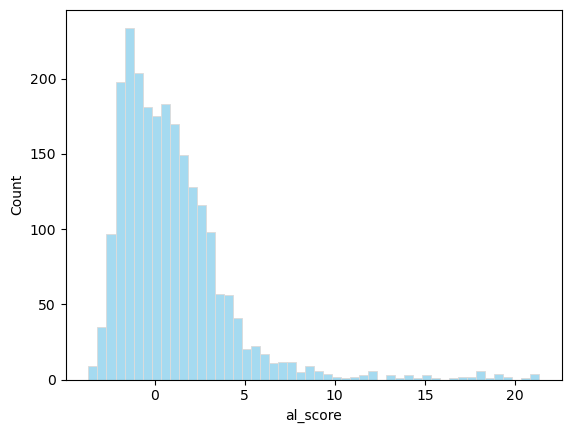

In [8]:
sns.histplot(data=selected, x='al_score', color="skyblue", edgecolor='gainsboro')

plt.show()